# HAM10000 - VGG+Inception+ViT (CB-Focal + Weighted Sampler)
Notebook huan luyen theo tung buoc, uu tien imbalance handling va chon model theo validation accuracy.

In [1]:
import os
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import autocast, GradScaler
from torchvision import transforms
from torchvision.models import vgg16

from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report
from tqdm import tqdm

In [2]:
# Optional: mount Google Drive when running on Colab
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        os.makedirs('/content/drive', exist_ok=True)
    drive.mount('/content/drive')
except Exception:
    pass

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Mounted at /content/drive
Device: cuda


In [3]:
@dataclass
class CFG:
    base_dir: str = '/content/drive/MyDrive/HAM10000'
    ckpt_dir: str = '/content/drive/MyDrive/DA_checkpoints/VGGxViT_CB_Focal'

    image_col: str = 'image_id'
    label_col: str = 'dx'

    img_size: int = 224
    num_classes: int = 7

    batch_size_train: int = 24
    batch_size_eval: int = 32
    num_workers: int = 2

    phase1_epochs: int = 18
    phase2_epochs: int = 12

    lr_phase1: float = 3e-4
    lr_phase2_head: float = 1.5e-4
    weight_decay: float = 1e-4
    warmup_ratio: float = 0.1
    grad_clip: float = 1.0

    focal_gamma: float = 2.0
    cb_beta: float = 0.9999

    use_amp: bool = True

cfg = CFG()
os.makedirs(cfg.ckpt_dir, exist_ok=True)
print('Checkpoint dir:', cfg.ckpt_dir)

Checkpoint dir: /content/drive/MyDrive/DA_checkpoints/VGGxViT_CB_Focal


In [4]:
def resolve_dataset_paths(df, image_col, part1_dir, part2_dir):
    out = df.copy()
    out[image_col] = out[image_col].astype(str).apply(lambda x: x if x.lower().endswith('.jpg') else x + '.jpg')

    if 'image_path' in out.columns:
        out['full_path'] = out['image_path'].where(
            out['image_path'].notna() & out['image_path'].astype(str).str.contains('HAM10000_images'),
            None
        )

    def find_image_path(img_name):
        for part_dir in [part1_dir, part2_dir]:
            p = os.path.join(part_dir, img_name)
            if os.path.exists(p):
                return p
        return None

    if 'full_path' not in out.columns:
        out['full_path'] = None

    mask = out['full_path'].isnull()
    out.loc[mask, 'full_path'] = out.loc[mask, image_col].apply(find_image_path)
    return out

def load_splits(config):
    split_dir = os.path.join(config.base_dir, 'splits')
    raw_dir = os.path.join(config.base_dir, 'raw')
    part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
    part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

    train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
    val_df = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
    test_df = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

    class_names = np.load(os.path.join(config.base_dir, 'class_names.npy'), allow_pickle=True).tolist()

    train_df = resolve_dataset_paths(train_df, config.image_col, part1_dir, part2_dir)
    val_df = resolve_dataset_paths(val_df, config.image_col, part1_dir, part2_dir)
    test_df = resolve_dataset_paths(test_df, config.image_col, part1_dir, part2_dir)

    for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        missing = int(df['full_path'].isnull().sum())
        if missing > 0:
            print(f'[WARN] Missing {missing} images in {name} split.')

    print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
    print('Class names:', class_names)
    print('Train distribution:')
    print(train_df[config.label_col].value_counts().sort_index())
    return train_df, val_df, test_df, class_names

train_df, val_df, test_df, class_names = load_splits(cfg)
class_to_idx = {c: i for i, c in enumerate(class_names)}

Train: 7010 | Val: 1502 | Test: 1503
Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train distribution:
dx
akiec     229
bcc       360
bkl       769
df         81
mel       779
nv       4693
vasc       99
Name: count, dtype: int64


In [5]:
def build_transforms(config):
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(config.img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    eval_tfms = transforms.Compose([
        transforms.Resize((config.img_size, config.img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tfms, eval_tfms

class HAM10000Dataset(Dataset):
    def __init__(self, df, class_to_idx, label_col='dx', transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['full_path']).convert('RGB')
        y = self.class_to_idx[row[self.label_col]]
        if self.transform is not None:
            img = self.transform(img)
        return img, y

def make_weighted_sampler(train_df, class_to_idx, label_col='dx'):
    y_idx = train_df[label_col].map(class_to_idx).astype(int).values
    class_count = np.bincount(y_idx, minlength=len(class_to_idx))

    # 1. Normalize weight "mềm hơn" (sqrt)
    class_weight = 1.0 / np.sqrt(np.maximum(class_count, 1))

    # 2. Giới hạn max sampling ratio
    max_ratio = 5.0
    ratio = class_weight / class_weight.min()
    ratio = np.minimum(ratio, max_ratio)
    class_weight = ratio

    sample_weight = class_weight[y_idx]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weight),
        num_samples=len(sample_weight),
        replacement=True,
    )
    return sampler, class_count, y_idx

def summarize_and_visualize_train_distribution(train_df, class_to_idx, label_col, sampler, y_idx, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    raw_counts = np.bincount(y_idx, minlength=len(class_to_idx))
    sampled_indices = list(iter(sampler))
    sampled_labels = y_idx[np.array(sampled_indices, dtype=np.int64)]
    sampled_counts = np.bincount(sampled_labels, minlength=len(class_to_idx))

    rows = []
    print('Train class distribution (raw -> sampler one epoch):')
    for i in range(len(class_to_idx)):
        cls_name = idx_to_class[i]
        raw_n = int(raw_counts[i])
        sampled_n = int(sampled_counts[i])
        ratio = sampled_n / max(1, raw_n)
        rows.append({
            'class_index': i,
            'class_name': cls_name,
            'raw_count': raw_n,
            'sampled_count': sampled_n,
            'sample_ratio': ratio,
        })
        print(f'  {cls_name:>8}: {raw_n:5d} -> {sampled_n:5d} (x{ratio:.2f})')

    df_stats = pd.DataFrame(rows)
    csv_path = os.path.join(out_dir, 'train_class_distribution.csv')
    fig_path = os.path.join(out_dir, 'train_class_distribution.png')
    df_stats.to_csv(csv_path, index=False)

    x = np.arange(len(df_stats))
    width = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, df_stats['raw_count'], width=width, label='Raw train')
    plt.bar(x + width / 2, df_stats['sampled_count'], width=width, label='Sampler one epoch')
    plt.xticks(x, df_stats['class_name'], rotation=45, ha='right')
    plt.ylabel('Number of images')
    plt.title('Train class distribution before/after balancing')
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_path, dpi=180)
    plt.show()

    print('Saved CSV:', csv_path)
    print('Saved plot:', fig_path)
    return df_stats

Train class distribution (raw -> sampler one epoch):
     akiec:   229 ->  1042 (x4.55)
       bcc:   360 ->   995 (x2.76)
       bkl:   769 ->  1038 (x1.35)
        df:    81 ->   945 (x11.67)
       mel:   779 ->   996 (x1.28)
        nv:  4693 ->  1016 (x0.22)
      vasc:    99 ->   978 (x9.88)


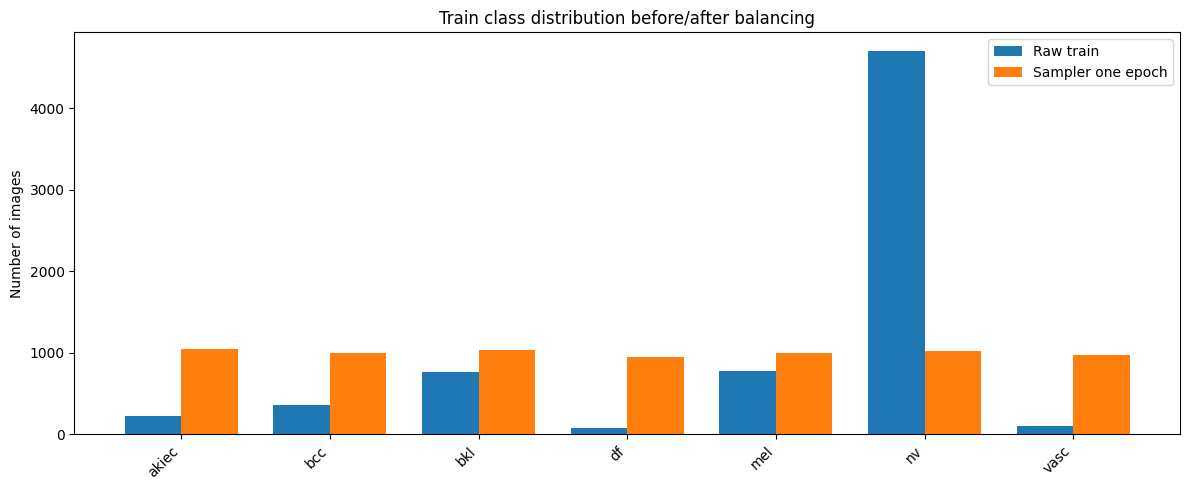

Saved CSV: /content/drive/MyDrive/DA_checkpoints/VGGxViT_CB_Focal/train_class_distribution.csv
Saved plot: /content/drive/MyDrive/DA_checkpoints/VGGxViT_CB_Focal/train_class_distribution.png


,class_index,class_name,raw_count,sampled_count,sample_ratio
0,0,akiec,229,1042,4.550218
1,1,bcc,360,995,2.763889
2,2,bkl,769,1038,1.349805
3,3,df,81,945,11.666667
4,4,mel,779,996,1.278562
5,5,nv,4693,1016,0.216493
6,6,vasc,99,978,9.878788


Batches | train: 293 | val: 47 | test: 47


In [6]:
train_tfms, eval_tfms = build_transforms(cfg)
train_ds = HAM10000Dataset(train_df, class_to_idx, cfg.label_col, transform=train_tfms)
val_ds = HAM10000Dataset(val_df, class_to_idx, cfg.label_col, transform=eval_tfms)
test_ds = HAM10000Dataset(test_df, class_to_idx, cfg.label_col, transform=eval_tfms)

sampler, class_count, y_idx = make_weighted_sampler(train_df, class_to_idx, cfg.label_col)
df_dist = summarize_and_visualize_train_distribution(train_df, class_to_idx, cfg.label_col, sampler, y_idx, cfg.ckpt_dir)
display(df_dist)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size_train, sampler=sampler, num_workers=cfg.num_workers, pin_memory=True, persistent_workers=(cfg.num_workers > 0))
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size_eval, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size_eval, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

print('Batches | train:', len(train_loader), '| val:', len(val_loader), '| test:', len(test_loader))

In [7]:
def conv_bn_relu(in_c, out_c, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )

class VGG16Blocks(nn.Module):
    def __init__(self, pretrained=True, to_pool3=True):
        super().__init__()
        vgg = vgg16(weights='IMAGENET1K_V1' if pretrained else None)
        if to_pool3:
            self.features = nn.Sequential(*list(vgg.features.children())[:17])
            self.out_channels = 256
        else:
            self.features = nn.Sequential(*list(vgg.features.children())[:10])
            self.out_channels = 128

    def forward(self, x):
        return self.features(x)

class InceptionV7(nn.Module):
    def __init__(self, in_channels=256, out_channels=512, branch_channels=128):
        super().__init__()
        b = branch_channels
        self.branch1 = conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0)
        self.branch2 = nn.Sequential(
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
        )
        self.branch3 = nn.Sequential(
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
            conv_bn_relu(b, b, kernel_size=(3, 1), stride=1, padding=(1, 0)),
            conv_bn_relu(b, b, kernel_size=(1, 3), stride=1, padding=(0, 1)),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            conv_bn_relu(in_channels, b, kernel_size=1, stride=1, padding=0),
        )
        self.proj = conv_bn_relu(b * 4, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x1 = self.branch1(x)
        x2 = self.branch2(x)
        x3 = self.branch3(x)
        x4 = self.branch4(x)
        out = torch.cat([x1, x2, x3, x4], dim=1)
        return self.proj(out)

In [8]:
class SpatialReducer(nn.Module):
    def __init__(self, in_channels=512, out_channels=512, stride=4):
        super().__init__()
        self.reduce = conv_bn_relu(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)

    def forward(self, x):
        return self.reduce(x)

class PatchEncoder(nn.Module):
    def __init__(self, in_c=512, emb_dim=64, grid_size=(7, 7)):
        super().__init__()
        self.grid_h, self.grid_w = grid_size
        self.num_patches = self.grid_h * self.grid_w
        self.proj = nn.Linear(in_c, emb_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, emb_dim) * 0.02)

    def forward(self, x):
        b, c, h, w = x.shape
        if h != self.grid_h or w != self.grid_w:
            raise ValueError(f'Expected grid {self.grid_h}x{self.grid_w}, got {h}x{w}')
        x = x.permute(0, 2, 3, 1).reshape(b, h * w, c)
        x = self.proj(x)
        return x + self.pos_embed

class ViTEncoder(nn.Module):
    def __init__(self, emb_dim=64, depth=6, heads=4, mlp_dim=192, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=emb_dim,
                nhead=heads,
                dim_feedforward=mlp_dim,
                dropout=dropout,
                batch_first=True,
                norm_first=True,
            ) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(emb_dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

class AttentionPool(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.attn = nn.Linear(emb_dim, 1)

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1)

class PlantXViT_v2(nn.Module):
    def __init__(self, num_classes=7, emb_dim=64):
        super().__init__()
        self.vgg = VGG16Blocks(pretrained=True, to_pool3=True)
        self.inception = InceptionV7(in_channels=self.vgg.out_channels, out_channels=512, branch_channels=128)
        self.reducer = SpatialReducer(in_channels=512, out_channels=512, stride=4)
        self.patch_encoder = PatchEncoder(in_c=512, emb_dim=emb_dim, grid_size=(7, 7))
        self.transformer = ViTEncoder(emb_dim=emb_dim, depth=6, heads=4, mlp_dim=192, dropout=0.1)
        self.attn_pool = AttentionPool(emb_dim)
        self.norm = nn.LayerNorm(emb_dim)
        self.drop = nn.Dropout(0.3)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        x = self.vgg(x)
        x = self.inception(x)
        x = self.reducer(x)
        x = self.patch_encoder(x)
        x = self.transformer(x)
        x = self.attn_pool(x)
        x = self.norm(x)
        x = self.drop(x)
        return self.classifier(x)

model = PlantXViT_v2(num_classes=cfg.num_classes, emb_dim=64).to(device)
print('Model initialized.')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 162MB/s]


Model initialized.


In [9]:
class CBFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999, gamma=2.0):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.clip(effective_num, a_min=1e-8, a_max=None)
        weights = weights / np.sum(weights) * len(samples_per_class)
        self.register_buffer('class_weights', torch.tensor(weights, dtype=torch.float32))
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none', weight=self.class_weights)
        pt = torch.exp(-ce)
        focal = ((1.0 - pt) ** self.gamma) * ce
        return focal.mean()

def cosine_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses, all_preds, all_targets = [], [], []
    for imgs, labels in tqdm(loader, desc='Eval', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(cfg.use_amp and device.type == 'cuda')):
            logits = model(imgs)
            loss = criterion(logits, labels)
        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = float(np.mean(losses)) if losses else 0.0
    acc = float(np.mean(np.array(all_preds) == np.array(all_targets))) if all_targets else 0.0
    macro_f1 = f1_score(all_targets, all_preds, average='macro')
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    return avg_loss, acc, macro_f1, bal_acc, all_targets, all_preds

def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    scaler = GradScaler(enabled=(cfg.use_amp and device.type == 'cuda'))
    running_loss, total = 0.0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', enabled=(cfg.use_amp and device.type == 'cuda')):
            logits = model(imgs)
            loss = criterion(logits, labels)
        if torch.isnan(loss):
            continue
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()
        bs = imgs.size(0)
        running_loss += loss.item() * bs
        total += bs
    return running_loss / max(1, total)

def save_ckpt_with_acc(path, model, optimizer, epoch, best_val_acc):
    state = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_val_acc,
    }
    torch.save(state, path)

criterion = CBFocalLoss(class_count, beta=cfg.cb_beta, gamma=cfg.focal_gamma).to(device)
print('Loss ready.')

Loss ready.


In [ ]:
# Phase 1 - freeze VGG backbone, train the remaining head/blocks
for p in model.vgg.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.lr_phase1,
    weight_decay=cfg.weight_decay,
 )
total_steps = len(train_loader) * cfg.phase1_epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler = cosine_with_warmup(optimizer, warmup_steps, total_steps)

best_val_acc = -1.0
best_path_phase1 = os.path.join(cfg.ckpt_dir, 'best_acc_phase1.pth')

for epoch in range(1, cfg.phase1_epochs + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
    val_loss, val_acc, val_macro_f1, val_bal_acc, _, _ = evaluate(model, val_loader, criterion)

    print(f'[Phase 1][Epoch {epoch}/{cfg.phase1_epochs}] ' f'Train Loss: {tr_loss:.4f} | ' f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_macro_f1:.4f} | Bal Acc: {val_bal_acc:.4f}')

    save_ckpt_with_acc(os.path.join(cfg.ckpt_dir, 'last_phase1_by_acc.pth'), model, optimizer, epoch, max(best_val_acc, val_acc))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_ckpt_with_acc(best_path_phase1, model, optimizer, epoch, best_val_acc)
        print(f'🔥 New best model found (Val Acc: {best_val_acc:.4f})')

Train:   0%|          | 0/293 [00:00<?, ?it/s]/tmp/ipykernel_8905/211123432.py:64: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[Phase 1][Epoch 1/18] Train Loss: 0.7061 | Val Loss: 0.1130 | Val Acc: 0.0639 | F1: 0.1626 | Bal Acc: 0.3732
🔥 New best model found (Val Acc: 0.0639)


[Phase 1][Epoch 2/18] Train Loss: 0.2936 | Val Loss: 0.0876 | Val Acc: 0.0905 | F1: 0.1712 | Bal Acc: 0.4339
🔥 New best model found (Val Acc: 0.0905)


[Phase 1][Epoch 3/18] Train Loss: 0.2027 | Val Loss: 0.0703 | Val Acc: 0.1212 | F1: 0.2118 | Bal Acc: 0.5201
🔥 New best model found (Val Acc: 0.1212)


[Phase 1][Epoch 4/18] Train Loss: 0.1607 | Val Loss: 0.0591 | Val Acc: 0.1684 | F1: 0.2786 | Bal Acc: 0.5857
🔥 New best model found (Val Acc: 0.1684)


Train:  91%|█████████ | 266/293 [02:06<00:11,  2.30it/s]

In [ ]:
# Phase 2 - unfreeze full model and finetune with differential LR
ckpt = torch.load(best_path_phase1, map_location=device)
model.load_state_dict(ckpt['model_state'], strict=True)

for p in model.parameters():
    p.requires_grad = True

backbone_params = list(model.vgg.parameters())
head_params = [p for n, p in model.named_parameters() if not n.startswith('vgg.')]

optimizer2 = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': cfg.lr_phase2_head * 0.3},
        {'params': head_params, 'lr': cfg.lr_phase2_head},
    ],
    weight_decay=cfg.weight_decay,
)

total_steps2 = len(train_loader) * cfg.phase2_epochs
warmup_steps2 = int(total_steps2 * cfg.warmup_ratio)
scheduler2 = cosine_with_warmup(optimizer2, warmup_steps2, total_steps2)

best_path_phase2 = os.path.join(cfg.ckpt_dir, 'best_acc_phase2.pth')

for epoch in range(1, cfg.phase2_epochs + 1):
    tr_loss = train_one_epoch(model, train_loader, optimizer2, criterion, scheduler2)
    val_loss, val_acc, val_macro_f1, val_bal_acc, _, _ = evaluate(model, val_loader, criterion)

    print(f'[Phase 2][Epoch {epoch}/{cfg.phase2_epochs}] ' f'Train Loss: {tr_loss:.4f} | ' f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_macro_f1:.4f} | Bal Acc: {val_bal_acc:.4f}')

    save_ckpt_with_acc(os.path.join(cfg.ckpt_dir, 'last_phase2_by_acc.pth'), model, optimizer2, epoch, max(best_val_acc, val_acc))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_ckpt_with_acc(best_path_phase2, model, optimizer2, epoch, best_val_acc)
        print(f'🔥 New best model found (Val Acc: {best_val_acc:.4f})')

In [ ]:
# Final test evaluation
final_best = best_path_phase2 if os.path.exists(best_path_phase2) else best_path_phase1
ckpt = torch.load(final_best, map_location=device)
model.load_state_dict(ckpt['model_state'], strict=True)

test_loss, test_acc, test_macro_f1, test_bal_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test macro-F1: {test_macro_f1:.4f}')
print(f'Test balanced-acc: {test_bal_acc:.4f}')

idx_to_class = {i: c for c, i in class_to_idx.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
print('\nBest checkpoint:', final_best)
print('Distribution CSV:', os.path.join(cfg.ckpt_dir, 'train_class_distribution.csv'))
print('Distribution plot:', os.path.join(cfg.ckpt_dir, 'train_class_distribution.png'))